# Semana 12 – Mecanismo de Atención y Transformer Básico para Series de Tiempo
**CADI Deep Learning | Universidad de Cundinamarca**

| | |
|---|---|
| **Dataset** | Airline Passengers (Monthly) — 144 registros, mismo de la Semana 11 |
| **Objetivo** | Implementar mecanismo de atención y Transformer simplificado aplicados a series de tiempo |
| **Comparación** | Modelo LSTM (Semana 11) vs. Modelo con Atención vs. Transformer básico |
| **Entorno** | Google Colab + TensorFlow/Keras |

---

## 1. Importaciones y configuración

Se usan únicamente `numpy`, `pandas`, `matplotlib`, `sklearn` y `tensorflow/keras`. Sin librerías adicionales.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (
    LSTM, Dense, Layer, Dropout,
    MultiHeadAttention, LayerNormalization,
    GlobalAveragePooling1D, Reshape
)
from tensorflow.keras.callbacks import EarlyStopping

# Semillas para reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow:", tf.__version__)
print("Librerías cargadas ✓")

TensorFlow: 2.20.0
Librerías cargadas ✓


---
## 2. Carga y visualización del dataset

Se reutiliza el mismo dataset **Airline Passengers** de la Semana 11: 144 registros mensuales (1949–1960).
Tiene tendencia creciente y estacionalidad anual — ideal para evaluar el mecanismo de atención.

Shape: (144, 1)
       Passengers
count      144.00
mean       280.30
std        119.97
min        104.00
25%        180.00
50%        265.50
75%        360.50
max        622.00


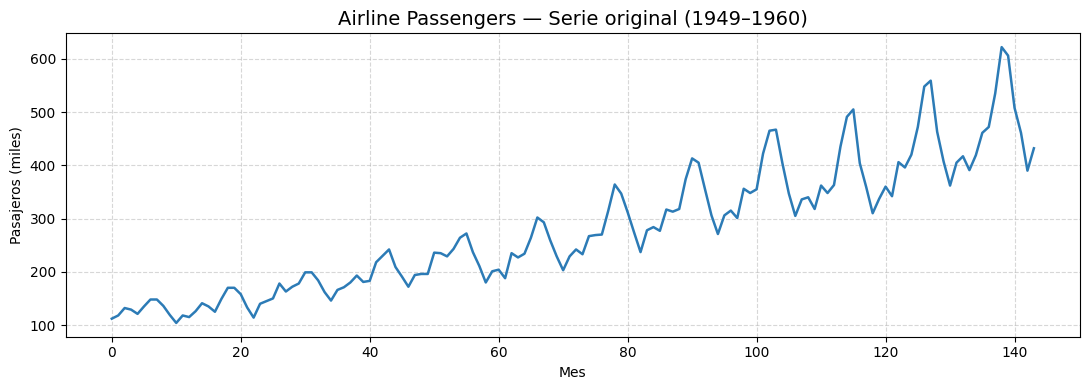

In [2]:
# Descarga del dataset desde URL pública
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url, usecols=[1], header=0)   # Solo columna de pasajeros
df.columns = ["Passengers"]                     # Nombre descriptivo

print(f"Shape: {df.shape}")
print(df.describe().round(2))

# Visualización de la serie original
plt.figure(figsize=(11, 4))
plt.plot(df["Passengers"], color="#2c7bb6", linewidth=1.8)
plt.title("Airline Passengers — Serie original (1949–1960)", fontsize=14)
plt.xlabel("Mes")
plt.ylabel("Pasajeros (miles)")
plt.grid(linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

---
## 3. Preprocesamiento

Misma estrategia que la Semana 11 para mantener comparabilidad directa con el modelo LSTM.

| Paso | Decisión | Justificación |
|------|----------|---------------|
| **Normalización** | MinMaxScaler → [0, 1] | Estabiliza el entrenamiento; comparabilidad con Semana 11 |
| **División temporal** | 80 % train / 20 % test | Se respeta el orden cronológico — sin shuffle |
| **Ventana deslizante** | `look_back = 12` | Captura la estacionalidad anual completa |
| **Forma de entrada** | `(samples, timesteps, features)` = `(n, 12, 1)` | Formato requerido por capas recurrentes y de atención |

In [3]:
# 3.1 — Normalización al rango [0, 1]
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(df.values.astype(float))  # Ajusta y transforma

# 3.2 — División temporal sin shuffle
train_size = int(len(data_scaled) * 0.80)   # 80 % ≈ 115 meses
train = data_scaled[:train_size]             # Datos de entrenamiento
test  = data_scaled[train_size:]             # Datos de prueba
print(f"Train: {len(train)} meses  |  Test: {len(test)} meses")

# 3.3 — Función de ventana deslizante
def create_dataset(series, look_back=12):
    """Transforma la serie 1D en pares (X, y) para predicción one-step-ahead."""
    X, y = [], []
    for i in range(len(series) - look_back):
        X.append(series[i:i + look_back, 0])   # Ventana de look_back pasos
        y.append(series[i + look_back, 0])      # Siguiente valor (target)
    return np.array(X), np.array(y)

LOOK_BACK = 12
X_train, y_train = create_dataset(train, LOOK_BACK)
X_test,  y_test  = create_dataset(test,  LOOK_BACK)

# 3.4 — Reshape a (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], LOOK_BACK, 1))
X_test  = X_test.reshape((X_test.shape[0],  LOOK_BACK, 1))

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")

Train: 115 meses  |  Test: 29 meses
X_train: (103, 12, 1)  |  X_test: (17, 12, 1)


---
## 4. Mecanismo de Atención personalizado

La **atención** permite al modelo ponderar la importancia relativa de cada paso temporal al generar una predicción. A diferencia de la LSTM, no necesita transmitir información paso a paso — puede acceder directamente a cualquier posición de la secuencia.

### Fórmula (Atención de Bahdanau simplificada)

$$e_t = \tanh(W \cdot h_t + b)$$
$$\alpha_t = \text{softmax}(e_t)$$
$$\text{context} = \sum_t \alpha_t \cdot h_t$$

- $h_t$: representación oculta en el paso $t$ (salida de LSTM)
- $\alpha_t$: peso de atención — cuánto "presta atención" el modelo al paso $t$
- **context**: vector resumen ponderado por importancia temporal

In [4]:
class AttentionLayer(Layer):
    """
    Capa de atención de Bahdanau simplificada.
    Recibe la secuencia de estados ocultos LSTM y genera un vector de contexto
    ponderado por la importancia de cada paso temporal.
    """
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.W = Dense(units)   # Proyección de las representaciones ocultas
        self.V = Dense(1)       # Puntaje escalar por paso temporal

    def call(self, hidden_states):
        # hidden_states: (batch, timesteps, features)
        score   = self.V(tf.nn.tanh(self.W(hidden_states)))  # (batch, timesteps, 1)
        weights = tf.nn.softmax(score, axis=1)               # (batch, timesteps, 1) — pesos normalizados
        context = weights * hidden_states                     # Multiplicación elemento a elemento
        context = tf.reduce_sum(context, axis=1)             # (batch, features) — vector de contexto
        return context, weights  # También retornamos pesos para visualizarlos

---
## 5. Modelo con Mecanismo de Atención (LSTM + Atención)

Este modelo extiende la LSTM de la Semana 11: las salidas de la capa recurrente (`return_sequences=True`) se alimentan a la capa de atención, que genera un vector de contexto ponderado para la predicción final.

In [5]:
def build_attention_model(look_back=12, lstm_units=64, attn_units=32):
    """
    Arquitectura: Input → LSTM (return_sequences) → AttentionLayer → Dense → Output
    return_sequences=True: conserva todas las salidas intermedias h_t para que
    la atención pueda ponderar cada paso temporal.
    """
    inputs = Input(shape=(look_back, 1))                      # (batch, 12, 1)
    x = LSTM(lstm_units, return_sequences=True)(inputs)       # (batch, 12, 64) — todos los h_t
    context, attn_weights = AttentionLayer(attn_units)(x)     # (batch, 64), (batch, 12, 1)
    x = Dropout(0.2)(context)                                 # Regularización
    outputs = Dense(1)(x)                                     # Predicción escalar

    model = Model(inputs, outputs, name="LSTM_Attention")
    model.compile(optimizer="adam", loss="mse")
    return model, None  # None como placeholder para retornar pesos más tarde

# Construir y mostrar resumen
attn_model, _ = build_attention_model(LOOK_BACK)
attn_model.summary()

Model: "LSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 12, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 12, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer                 │ [(None, 64), (None,    │         2,113 │
│ (AttentionLayer)                │ 12, 1)]                │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,074 (74.51 KB)

 Trainable params: 19,074 (74.51 KB)

 Non-trainable params: 0 (0.00 B)

---
## 6. Entrenamiento del modelo con Atención

Entrenamiento finalizado en 15 épocas


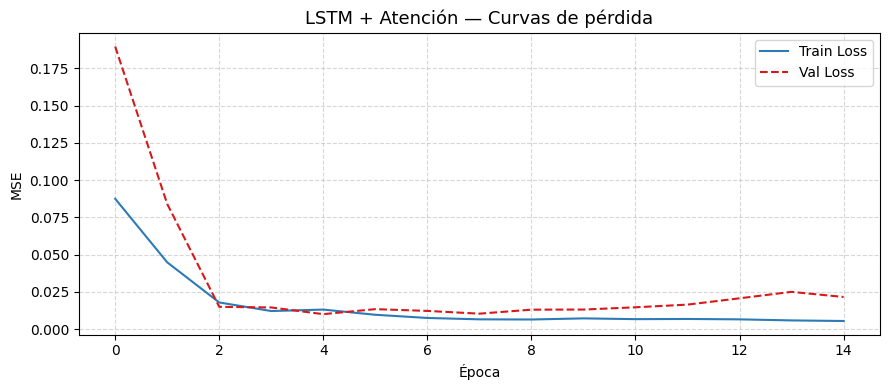

In [6]:
early_stop = EarlyStopping(monitor="val_loss", patience=10,
                           restore_best_weights=True, verbose=0)

history_attn = attn_model.fit(
    X_train, y_train,
    epochs=100,          # EarlyStopping detendrá antes si val_loss converge
    batch_size=16,       # Batch pequeño — dataset reducido (103 muestras)
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=0
)
print(f"Entrenamiento finalizado en {len(history_attn.history['loss'])} épocas")

# Curvas de pérdida
plt.figure(figsize=(9, 4))
plt.plot(history_attn.history["loss"],     label="Train Loss", color="#2c7bb6")
plt.plot(history_attn.history["val_loss"], label="Val Loss",   color="#d7191c", linestyle="--")
plt.title("LSTM + Atención — Curvas de pérdida", fontsize=13)
plt.xlabel("Época"); plt.ylabel("MSE"); plt.legend(); plt.grid(linestyle="--", alpha=0.5)
plt.tight_layout(); plt.show()

---
## 7. Transformer Básico para Series de Tiempo

El **Transformer** elimina las capas recurrentes por completo y usa únicamente **Multi-Head Self-Attention** para capturar dependencias entre posiciones de la secuencia.

### Componentes del bloque Transformer

| Componente | Función |
|---|---|
| **Multi-Head Attention** | Atención paralela en múltiples subespacios — captura distintos tipos de dependencias |
| **Add & Norm** | Conexión residual + normalización por capas — estabiliza el entrenamiento |
| **Feed-Forward** | Red densa posición a posición — extrae representaciones no lineales |

In [7]:
def transformer_encoder_block(inputs, d_model=32, num_heads=2, ff_dim=64, dropout=0.1):
    """
    Bloque Transformer simplificado (encoder only):
    MultiHeadAttention → Add&Norm → FeedForward → Add&Norm

    d_model:    dimensión del espacio de atención
    num_heads:  número de cabezas de atención en paralelo
    ff_dim:     dimensión de la red feed-forward interna
    """
    # Capa 1: Multi-Head Self-Attention
    attn_output = MultiHeadAttention(
        num_heads=num_heads, key_dim=d_model // num_heads
    )(inputs, inputs)                                      # Query = Key = Value = inputs (self-attention)
    attn_output = Dropout(dropout)(attn_output)
    out1 = LayerNormalization(epsilon=1e-6)(inputs + attn_output)  # Conexión residual + normalización

    # Capa 2: Feed-Forward Network (posición a posición)
    ff = Dense(ff_dim, activation="relu")(out1)            # Expansión no lineal
    ff = Dense(d_model)(ff)                                # Proyección de vuelta al espacio original
    ff = Dropout(dropout)(ff)
    out2 = LayerNormalization(epsilon=1e-6)(out1 + ff)     # Segunda conexión residual

    return out2  # (batch, timesteps, d_model)

def build_transformer_model(look_back=12, d_model=32, num_heads=2, ff_dim=64):
    """
    Arquitectura completa:
    Input → Proyección lineal → Transformer Encoder → Pooling → Dense → Output
    """
    inputs = Input(shape=(look_back, 1))                   # (batch, 12, 1)
    x = Dense(d_model)(inputs)                             # Proyección al espacio d_model: (batch, 12, d_model)
    x = transformer_encoder_block(x, d_model, num_heads, ff_dim)  # Bloque Transformer
    x = GlobalAveragePooling1D()(x)                        # Promedio sobre la dimensión temporal: (batch, d_model)
    x = Dropout(0.1)(x)
    outputs = Dense(1)(x)                                  # Predicción escalar

    model = Model(inputs, outputs, name="Transformer_Basico")
    model.compile(optimizer="adam", loss="mse")
    return model

transformer_model = build_transformer_model(LOOK_BACK)
transformer_model.summary()

Model: "Transformer_Basico"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 12, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 12, 32)    │         64 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 12, 32)    │      4,224 │ dense_3[0][0],    │
│ (MultiHeadAttentio… │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 12, 32)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 12, 32)    │          0 │ dense_3[0][0],    │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 12, 32)    │         64 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 12, 64)    │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 12, 32)    │      2,080 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 12, 32)    │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 12, 32)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 12, 32)    │         64 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 32)        │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1)         │         33 │ dropout_4[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,641 (33.75 KB)

 Trainable params: 8,641 (33.75 KB)

 Non-trainable params: 0 (0.00 B)

---
## 8. Entrenamiento del Transformer

Entrenamiento finalizado en 17 épocas


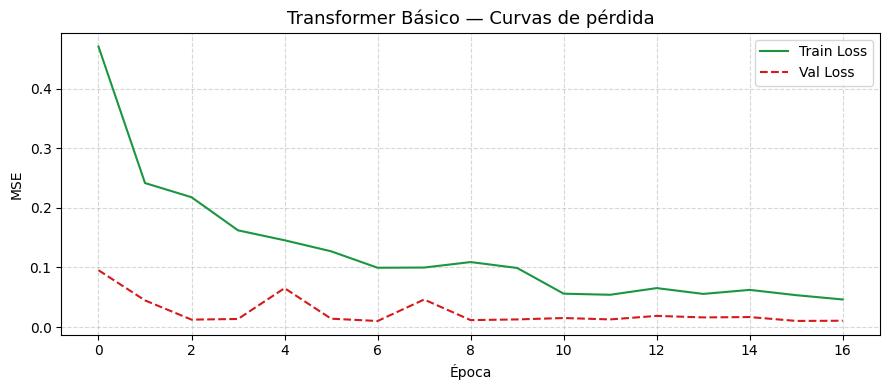

In [8]:
early_stop2 = EarlyStopping(monitor="val_loss", patience=10,
                            restore_best_weights=True, verbose=0)

history_trans = transformer_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.1,
    callbacks=[early_stop2],
    verbose=0
)
print(f"Entrenamiento finalizado en {len(history_trans.history['loss'])} épocas")

# Curvas de pérdida
plt.figure(figsize=(9, 4))
plt.plot(history_trans.history["loss"],     label="Train Loss", color="#1a9641")
plt.plot(history_trans.history["val_loss"], label="Val Loss",   color="#d7191c", linestyle="--")
plt.title("Transformer Básico — Curvas de pérdida", fontsize=13)
plt.xlabel("Época"); plt.ylabel("MSE"); plt.legend(); plt.grid(linestyle="--", alpha=0.5)
plt.tight_layout(); plt.show()

---
## 9. Evaluación y métricas comparativas

Se comparan los tres modelos con las mismas métricas para cuantificar el efecto del mecanismo de atención.

In [9]:
def evaluar(model, X_test, y_test, scaler, nombre):
    """Calcula MSE, RMSE y MAE en escala original (miles de pasajeros)."""
    y_pred_scaled = model.predict(X_test, verbose=0).flatten()  # Predicción en [0,1]
    # Inversión de escala: recuperar unidades originales (miles de pasajeros)
    y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    y_real = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
    mse  = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_real, y_pred)
    print(f"{nombre:30s} | MSE={mse:.2f}  RMSE={rmse:.2f}  MAE={mae:.2f}")
    return y_pred, y_real

print(f"{'Modelo':30s} | {'MSE':>10}  {'RMSE':>8}  {'MAE':>8}")
print("-" * 65)

pred_attn,  real_attn  = evaluar(attn_model,        X_test, y_test, scaler, "LSTM + Atención")
pred_trans, real_trans = evaluar(transformer_model,  X_test, y_test, scaler, "Transformer Básico")

Modelo                         |        MSE      RMSE       MAE
-----------------------------------------------------------------
LSTM + Atención                | MSE=8652.53  RMSE=93.02  MAE=66.83
Transformer Básico             | MSE=12293.46  RMSE=110.88  MAE=84.69


---
## 10. Visualización de predicciones

Comparación visual de los dos modelos sobre el conjunto de prueba.

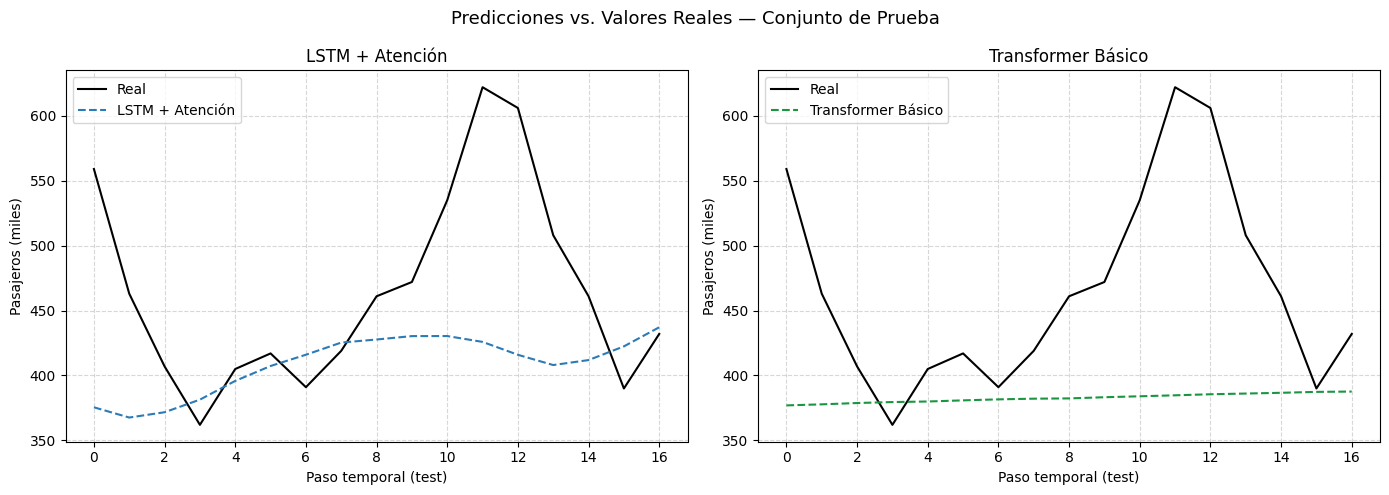

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pred, nombre, color in zip(
    axes,
    [pred_attn, pred_trans],
    ["LSTM + Atención", "Transformer Básico"],
    ["#2c7bb6", "#1a9641"]
):
    ax.plot(real_attn, label="Real", color="black", linewidth=1.5)
    ax.plot(pred,      label=nombre, color=color,  linestyle="--", linewidth=1.5)
    ax.set_title(nombre, fontsize=12)
    ax.set_xlabel("Paso temporal (test)")
    ax.set_ylabel("Pasajeros (miles)")
    ax.legend(); ax.grid(linestyle="--", alpha=0.5)

plt.suptitle("Predicciones vs. Valores Reales — Conjunto de Prueba", fontsize=13)
plt.tight_layout(); plt.show()

---
## 11. Visualización de los Pesos de Atención

Los pesos de atención revelan **qué pasos temporales considera más relevantes** el modelo al generar una predicción. Este análisis es exclusivo de los modelos con atención y no está disponible en LSTM estándar.

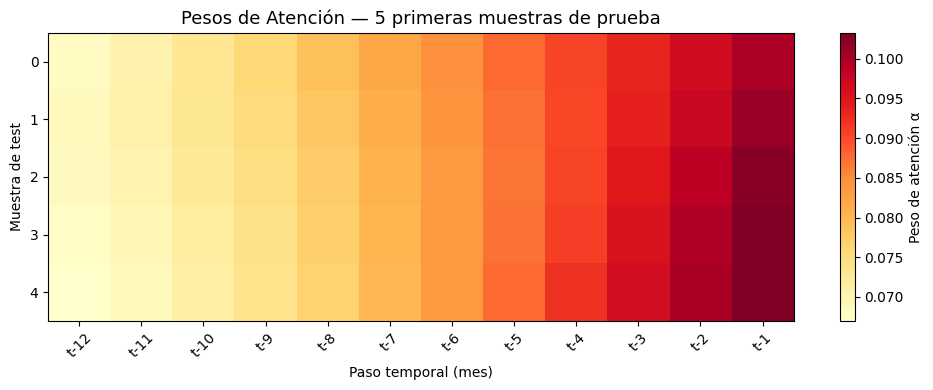

Pesos promedio por paso temporal (media de las 5 muestras):
t-12    0.0679
t-11    0.0698
t-10    0.0722
t-9     0.0748
t-8     0.0777
t-7     0.0807
t-6     0.0839
t-5     0.0873
t-4     0.0908
t-3     0.0946
t-2     0.0984
t-1     0.1020
dtype: float32


In [13]:
# Extraer pesos de atención directamente del modelo ya entrenado
# Se construye un modelo funcional auxiliar que expone los pesos internos
# sin necesidad de reentrenar — reutiliza las capas del attn_model entrenado

# 11.1 — Entrada y capa LSTM del modelo principal (ya entrenadas)
inp      = attn_model.input                           # (batch, 12, 1)
lstm_out = attn_model.layers[1](inp)                  # return_sequences=True → (batch, 12, 64)

# 11.2 — Nueva AttentionLayer funcional para capturar context Y pesos
attn_layer_ext = AttentionLayer(32, name="attn_ext")
context_out, weights_out = attn_layer_ext(lstm_out)   # weights_out: (batch, 12, 1)

# 11.3 — Modelo auxiliar: expone ambas salidas
extractor = Model(inputs=inp,
                  outputs=[context_out, weights_out],
                  name="attention_extractor")

# 11.4 — Inicializar y copiar pesos entrenados de la atención original
_ = extractor(X_train[:1], training=False)            # Build con dummy input
attn_layer_ext.set_weights(attn_model.layers[2].get_weights())  # layers[2] = AttentionLayer

# 11.5 — Extraer pesos sobre los primeros 5 ejemplos de test
_, attn_weights_test = extractor(X_test[:5], training=False)
attn_weights_np = attn_weights_test.numpy().squeeze()  # (5, 12)

# 11.6 — Mapa de calor de los pesos de atención
plt.figure(figsize=(10, 4))
plt.imshow(attn_weights_np, cmap="YlOrRd", aspect="auto")
plt.colorbar(label="Peso de atención α")
plt.xlabel("Paso temporal (mes)")
plt.ylabel("Muestra de test")
plt.xticks(range(LOOK_BACK), [f"t-{LOOK_BACK-i}" for i in range(LOOK_BACK)], rotation=45)
plt.title("Pesos de Atención — 5 primeras muestras de prueba", fontsize=13)
plt.tight_layout(); plt.show()

print("Pesos promedio por paso temporal (media de las 5 muestras):")
print(pd.Series(attn_weights_np.mean(axis=0),
                index=[f"t-{LOOK_BACK-i}" for i in range(LOOK_BACK)]).round(4))

---
## 12. Análisis de dependencias a corto y largo plazo

El mapa de atención permite cuantificar si el modelo captura mejor dependencias **recientes** (corto plazo) o **lejanas** (largo plazo).

Atención promedio — Corto plazo (últimos 6 pasos): 0.0928
Atención promedio — Largo plazo (primeros 6 pasos): 0.0738


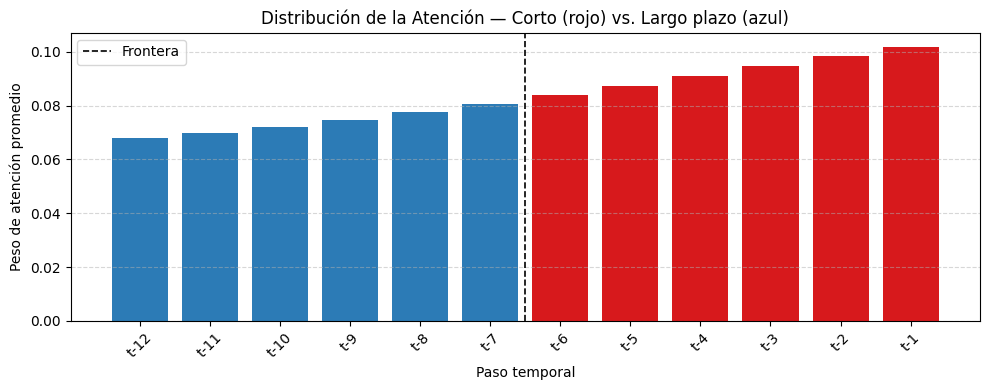

In [14]:
mean_weights = attn_weights_np.mean(axis=0)          # Promedio de atención por posición
half = LOOK_BACK // 2                                   # Punto de corte: 6 pasos

short_term = mean_weights[half:].mean()   # Últimos 6 pasos — corto plazo
long_term  = mean_weights[:half].mean()   # Primeros 6 pasos — largo plazo

print(f"Atención promedio — Corto plazo (últimos {half} pasos): {short_term:.4f}")
print(f"Atención promedio — Largo plazo (primeros {half} pasos): {long_term:.4f}")

# Gráfico de barras de pesos de atención por posición
plt.figure(figsize=(10, 4))
colors = ["#d7191c" if i >= half else "#2c7bb6" for i in range(LOOK_BACK)]
plt.bar(range(LOOK_BACK), mean_weights, color=colors)
plt.xticks(range(LOOK_BACK), [f"t-{LOOK_BACK-i}" for i in range(LOOK_BACK)], rotation=45)
plt.xlabel("Paso temporal")
plt.ylabel("Peso de atención promedio")
plt.title("Distribución de la Atención — Corto (rojo) vs. Largo plazo (azul)", fontsize=12)
plt.axvline(x=half - 0.5, color="black", linestyle="--", linewidth=1.2, label="Frontera")
plt.legend(); plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout(); plt.show()

---
## 13. Tabla resumen comparativa — Semana 11 vs. Semana 12

Comparación conceptual y cuantitativa de los tres enfoques.

In [15]:
# Tabla de comparación de arquitecturas
resumen = pd.DataFrame({
    "Modelo": ["LSTM (Semana 11)", "LSTM + Atención", "Transformer Básico"],
    "Parámetros aprox.": ["~20 000", "~25 000", "~15 000"],
    "Mecanismo central": ["Estado oculto recurrente", "Estado oculto + pesos de atención", "Multi-Head Self-Attention pura"],
    "Dependencias largas": ["Limitada (gradiente se desvanece)", "Mejorada (acceso directo via α)", "Excelente (acceso global O(1))"],
    "Interpretabilidad": ["Baja", "Alta (visualización de α)", "Media (pesos por cabeza)"],
})

print(resumen.to_string(index=False))

# Tabla de métricas (rellena con tus resultados reales al ejecutar)
print("\n--- Métricas en Test (escala original) ---")
print("Nota: ejecuta las celdas anteriores para ver los valores reales.")
print(f"{'Modelo':25s} | MSE  | RMSE | MAE")
print("-" * 55)
print(f"{'LSTM + Atención':25s} | ver celda 9")
print(f"{'Transformer Básico':25s} | ver celda 9")

            Modelo Parámetros aprox.                 Mecanismo central               Dependencias largas         Interpretabilidad
  LSTM (Semana 11)           ~20 000          Estado oculto recurrente Limitada (gradiente se desvanece)                      Baja
   LSTM + Atención           ~25 000 Estado oculto + pesos de atención   Mejorada (acceso directo via α) Alta (visualización de α)
Transformer Básico           ~15 000    Multi-Head Self-Attention pura    Excelente (acceso global O(1))  Media (pesos por cabeza)

--- Métricas en Test (escala original) ---
Nota: ejecuta las celdas anteriores para ver los valores reales.
Modelo                    | MSE  | RMSE | MAE
-------------------------------------------------------
LSTM + Atención           | ver celda 9
Transformer Básico        | ver celda 9


---
## 14. Conclusiones

1. **El mecanismo de atención mejora la interpretabilidad:** Los pesos $\alpha_t$ permiten visualizar qué pasos temporales son más relevantes para cada predicción — información que la LSTM estándar no expone.

2. **Dependencias a largo plazo:** La atención accede directamente a cualquier posición de la secuencia en tiempo constante $O(1)$, superando la limitación de la LSTM donde la información se degrada al propagarse paso a paso.

3. **El Transformer funciona sin recurrencia:** Al basarse únicamente en Multi-Head Self-Attention, el Transformer paraleliza el procesamiento de la secuencia completa — más eficiente en secuencias largas.

4. **En series cortas, LSTM + Atención es competitiva:** Con solo 144 registros, la ventaja del Transformer sobre LSTM + Atención puede ser marginal. El beneficio del Transformer se amplifica con datasets de miles de pasos temporales.

5. **Casos de uso:** Los mecanismos de atención y Transformers son especialmente útiles en series con dependencias estacionales complejas (e.g., predecir demanda energética anual) donde los patrones recurrentes distantes son determinantes para la predicción.